In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

import BOPackageBenchmarking as BOPackage

In [53]:
import psutil

# Get the total and available memory in GB
memory_info = psutil.virtual_memory()
total_memory_gb = memory_info.total / (1024 ** 3)
available_memory_gb = memory_info.available / (1024 ** 3)

print(f"Total Memory: {total_memory_gb:.2f} GB")
print(f"Available Memory: {available_memory_gb:.2f} GB")

Total Memory: 16.00 GB
Available Memory: 6.83 GB


In [3]:
def Ackley(X):
        n = X.shape[1]  # Number of dimensions (should be 20 for this problem)
        
        # Calculate the objective function value for each row in X
        term1 = -20 * np.exp(-0.2 * np.sqrt(np.sum(X**2, axis=1) / n))
        term2 = -np.exp(np.sum(np.cos(2 * np.pi * X), axis=1) / n)
        y = term1 + term2 + 20 + np.e
        
        # Make function negative to find the minimum
        y = -y.reshape(-1, 1)
        
        return y

In [54]:
log_path = '/Users/jordanlee/Projects/SummerProject/Bayesian/Benchmarking/TimeComplexity/log.txt'

Kernel = BOPackage.RBF_Kernel
length_scale = 0.1

AcquisitionFunction = BOPackage.UpperConfidenceBound
max_kappa = 10
min_kappa = 0.1
acquisition_samples = 1000

bounds = np.array([[0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]])

# Optional batch size parameters
random_batch_size = 10000
batch_size = 16

# Create the object
bo = BOPackage.BO(KernelFunction=Kernel, 
                  length_scale=length_scale, 
                  AcquisitionFunction=AcquisitionFunction, 
                  bounds=bounds, 
                  acquisition_samples=acquisition_samples,
                  log_path=log_path
                  )

# Get X
raw_X = bo.GetRandomXBatch(batch_size=random_batch_size)

# Calculate Y
raw_y = Ackley(raw_X)
bo.UpdateData(raw_X, raw_y)

for i in range(1):
    raw_X = bo.GetNextXBatch(batch_size=batch_size, max_kappa=max_kappa, min_kappa=min_kappa)
    raw_y = Ackley(np.array(raw_X))
    bo.UpdateData(raw_X, raw_y)

In [61]:
a = 1000
batch_size = 16
n = [1, 100, 1000, 2500, 5000, 7500, 10000]

K = [3.814697265625e-07, 8.33272933959961e-06, 0.0006922165552775065, 0.003815917174021403, 0.014458894729614258, 0.055944085121154785, 0.18941239913304647]
invert_kernel = [3.139177958170573e-07, 0.0005981326103210449, 0.0005342841148376464, 0.005164003372192383, 0.030060696601867675, 0.07622033754984538, 0.1782017668088277]
standardise_X = [9.179115295410156e-07, 6.69558842976888e-06, 4.851818084716797e-06, 1.4547506968180338e-05, 1.8970171610514322e-05, 7.935365041097005e-06, 1.4813741048177083e-05]
K_star = [7.669130961100261e-07, 5.756616592407226e-05, 0.0006123503049214681, 0.0015923817952473958, 0.003786003589630127, 0.005466898282368978, 0.007330131530761719]
K_star_star = [0.0006130536397298177, 0.0006673653920491536, 0.0005720178286234538, 0.0006449222564697266, 0.0005731344223022461, 0.0005787014961242676 , 0.0005902489026387533]
mean = [7.947285970052083e-08, 1.4730294545491536e-05, 0.00024618307749430337, 0.0015188177426656087, 0.11398675044377644, 0.005440918604532877, 0.011123168468475341, 0.018599283695220948]

All_X = [0.010959752400716146, 0.0150430162747701, 0.0367385466893514, 0.11538140376408895, 0.31389865080515544, 0.6383726159731548, 1.0423689444859823]

In [88]:
import math

n_diffs = [n[i+1] / n[i] for i in range(len(n) - 1)]
K_diffs = [K[i+1] / K[i] for i in range(len(K) - 1)]
invert_K_diffs = [invert_kernel[i+1] / invert_kernel[i] for i in range(len(invert_kernel) - 1)]
K_star_diffs = [K_star[i+1] / K_star[i] for i in range(len(K_star) - 1)]
K_star_star_diffs = [K_star_star[i+1] / K_star_star[i] for i in range(len(K_star_star) - 1)]
All_X_diffs = [All_X[i+1] / All_X[i] for i in range(len(All_X) - 1)]

K_scaling = [math.log(np.array(K_diffs[i]), np.array(n_diffs[i])) for i in range(len(n_diffs))]
invert_K_scaling = [math.log(np.array(invert_K_diffs[i]), np.array(n_diffs[i])) for i in range(len(n_diffs))]
K_star_scaling = [math.log(np.array(K_star_diffs[i]), np.array(n_diffs[i])) for i in range(len(n_diffs))]
K_star_star_scaling = [math.log(np.array(K_star_star_diffs[i]), np.array(n_diffs[i])) for i in range(len(n_diffs))]
All_X_scaling = [math.log(np.array(All_X_diffs[i]), np.array(n_diffs[i])) for i in range(len(n_diffs))]

2.325047762412552 [0.6696635987128876, 1.9194547063370562, 1.8629867357774246, 1.921855511120623, 3.3370144741907217, 4.239311548336597]


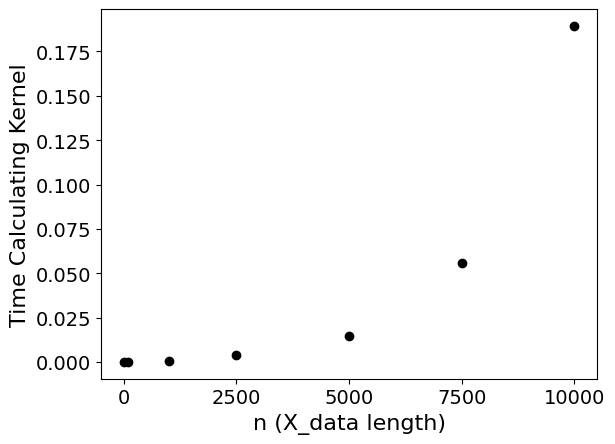

In [96]:
plt.scatter(n, np.array(K), color='k')

plt.xticks([0, 2500, 5000, 7500, 10000], fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('n (X_data length)', fontsize=16)
plt.ylabel('Time Calculating Kernel', fontsize=16)

print(np.mean(K_scaling), K_scaling)

1.9758194736312908 [1.639990772294372, -0.04902521881605529, 2.4757858814268996, 2.5413165936050235, 2.29467282803083, 2.9521759852466753]


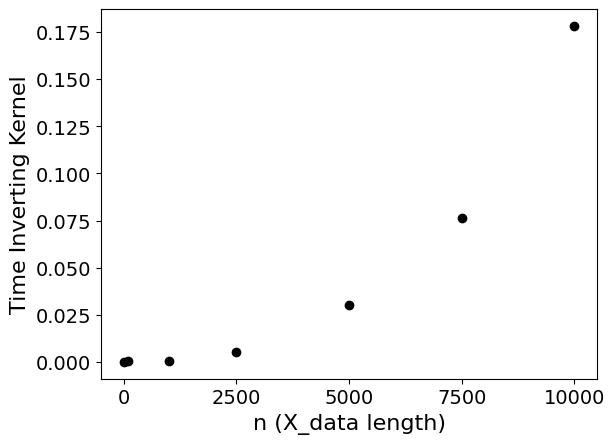

In [95]:
plt.scatter(n, np.array(invert_kernel), color='k')

plt.xticks([0, 2500, 5000, 7500, 10000], fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('n (X_data length)', fontsize=16)
plt.ylabel('Time Inverting Kernel', fontsize=16)

print(np.mean(invert_K_scaling), invert_K_scaling)

1.030434832262655 [0.9377105755561174, 1.0268326333081035, 1.0429895371879656, 1.2494894957441283, 0.9061209108361241, 1.0194658409434918]


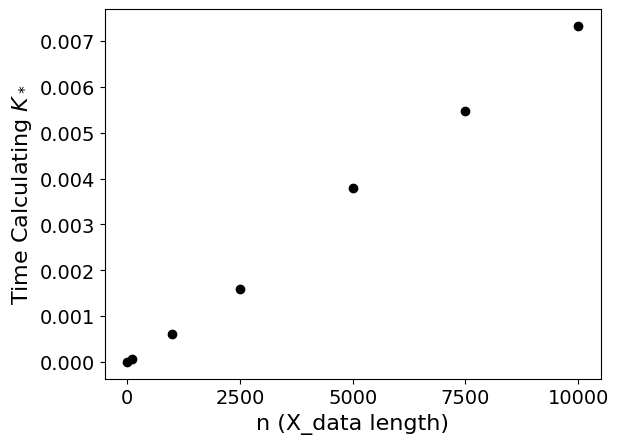

In [94]:
plt.scatter(n, np.array(K_star), color='k')

plt.xticks([0, 2500, 5000, 7500, 10000], fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('n (X_data length)', fontsize=16)
plt.ylabel('Time Calculating $K_*$', fontsize=16)

print(np.mean(K_star_scaling), K_star_scaling)

0.000777396246097399 [0.018432603120640958, -0.06695411637110212, 0.13091872801607204, -0.17025171152411772, 0.023840549050501793, 0.06867832518458943]


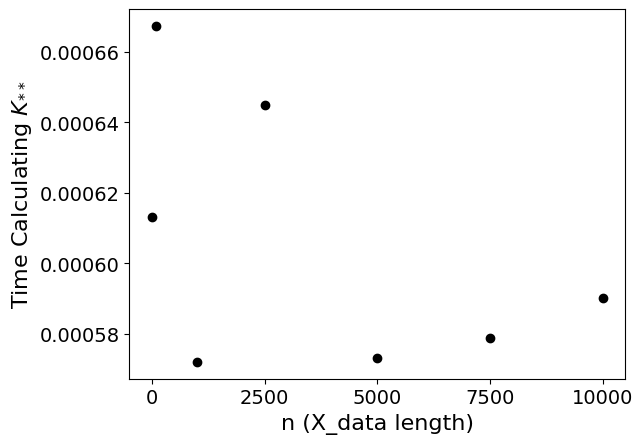

In [93]:
plt.scatter(n, np.array(K_star_star), color='k')

plt.xticks([0, 2500, 5000, 7500, 10000], fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('n (X_data length)', fontsize=16)
plt.ylabel('Time Calculating $K_{**}$', fontsize=16)

print(np.mean(K_star_star_scaling), K_star_star_scaling)

1.100755414025041 [0.06876709127336561, 0.3877870470417528, 1.2489667667850068, 1.4438881070909542, 1.7507104078025246, 1.704413064156641]


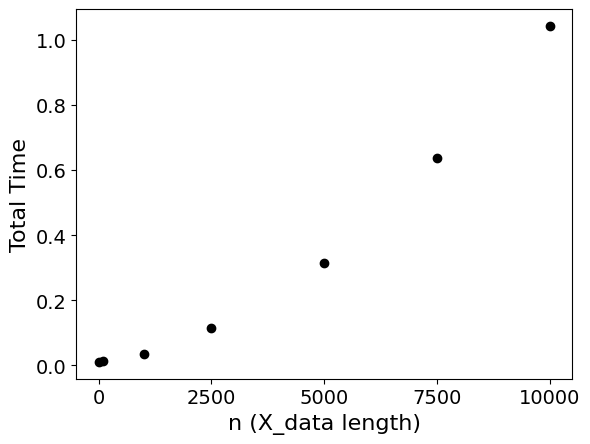

In [97]:
plt.scatter(n, np.array(All_X), color='k')

plt.xticks([0, 2500, 5000, 7500, 10000], fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('n (X_data length)', fontsize=16)
plt.ylabel('Total Time', fontsize=16)

print(np.mean(All_X_scaling), All_X_scaling)

In [99]:
n = 1000
batch_size = 16
a = [10, 100, 250, 500, 1000, 2500, 5000, 7500, 9000, 10000]

K = [0.0005983511606852213, 0.0006553490956624348, 0.0007251342137654623, 0.0006823857625325521, 0.0007169047991434733, 0.0007191499074300131, 0.000689999262491862, 0.0008178313573201497, 0.0007730801900227865, 0.0007021824518839518]
invert_kernel = [0.0004537463188171387, 0.0004553675651550293, 0.0004262685775756836, 0.0005296826362609863, 0.0005517681439717611, 0.0005593697230021158, 0.0004183689753214518, 0.00044788519541422525, 0.0006339470545450846, 0.00046538114547729493]
standardise_X = [1.1165936787923178e-06, 1.2516975402832031e-06, 2.018610636393229e-06, 2.2292137145996093e-06, 6.9499015808105465e-06, 4.915396372477214e-06, 4.784266153971354e-06, 4.482269287109375e-06, 5.40018081665039e-06, 5.348523457845052e-06]
K_star = [4.605452219645182e-06, 5.1867961883544925e-05, 0.00012349685033162435, 0.000289920965830485, 0.0008281310399373373, 0.0018339157104492188, 0.003527180353800456, 0.004714349905649821, 0.005214830239613851, 0.006099935372670492]
K_star_star = [2.3047129313151042e-07, 4.684925079345703e-06, 3.521442413330078e-05, 0.00013586680094401042, 0.0008251547813415527, 0.004269349575042725, 0.015217844645182292, 0.03343313535054525, 0.05503346920013428, 0.087776251633962]
mean = [6.830692291259765e-06, 3.4471352895100914e-05, 7.985035578409831e-05, 0.00022771755854288737, 0.00040167967478434244, 0.0005501468976338704, 0.001035451889038086, 0.001534100373586019, 0.001737364133199056, 0.002573684851328532]

All_X = [0.002022198836008708, 0.00399173895517985, 0.008057880401611327, 0.020304544766743978, 0.046777900060017905, 0.1398173451423645, 0.4228565812110901, 0.9523125847180685, 1.4083338499069213, 1.9590804815292358]

In [101]:
import math

a_diffs = [a[i+1] / a[i] for i in range(len(a) - 1)]
K_diffs = [K[i+1] / K[i] for i in range(len(K) - 1)]
invert_K_diffs = [invert_kernel[i+1] / invert_kernel[i] for i in range(len(invert_kernel) - 1)]
K_star_diffs = [K_star[i+1] / K_star[i] for i in range(len(K_star) - 1)]
K_star_star_diffs = [K_star_star[i+1] / K_star_star[i] for i in range(len(K_star_star) - 1)]
All_X_diffs = [All_X[i+1] / All_X[i] for i in range(len(All_X) - 1)]

K_scaling = [math.log(np.array(K_diffs[i]), np.array(a_diffs[i])) for i in range(len(a_diffs))]
invert_K_scaling = [math.log(np.array(invert_K_diffs[i]), np.array(a_diffs[i])) for i in range(len(a_diffs))]
K_star_scaling = [math.log(np.array(K_star_diffs[i]), np.array(a_diffs[i])) for i in range(len(a_diffs))]
K_star_star_scaling = [math.log(np.array(K_star_star_diffs[i]), np.array(a_diffs[i])) for i in range(len(a_diffs))]
All_X_scaling = [math.log(np.array(All_X_diffs[i]), np.array(a_diffs[i])) for i in range(len(a_diffs))]

-0.08058004557746917 [0.03951656665514472, 0.1104329581243842, -0.08766049940935233, 0.07119400377795455, 0.0034124269553179715, -0.05969771319954522, 0.4191868019353728, -0.308649014276021, -0.9129559407604784]


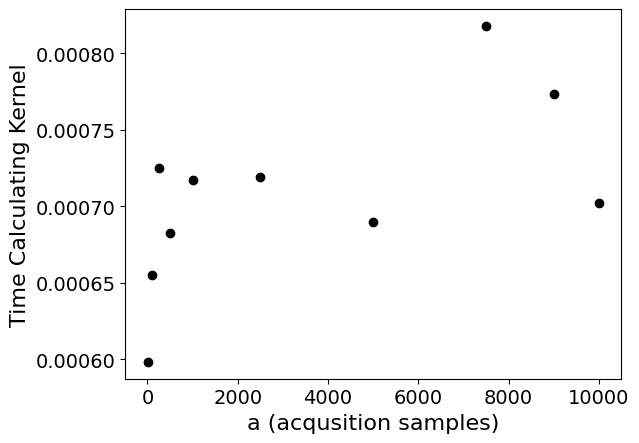

In [102]:
plt.scatter(a, np.array(K), color='k')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('a (acqusition samples)', fontsize=16)
plt.ylabel('Time Calculating Kernel', fontsize=16)

print(np.mean(K_scaling), K_scaling)

-0.10693506872282427 [0.0015489788400986641, -0.07206808345066747, 0.3133655050112867, 0.058933950050777825, 0.014932734519616393, -0.4190262965084769, 0.1681357501182777, 1.9055810379176519, -2.9338191950039834]


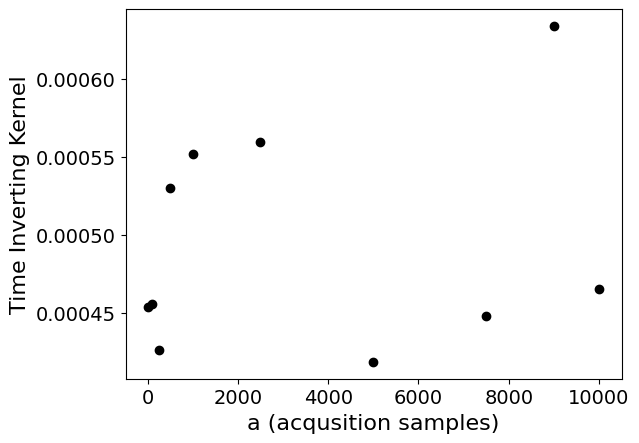

In [103]:
plt.scatter(a, np.array(invert_kernel), color='k')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('a (acqusition samples)', fontsize=16)
plt.ylabel('Time Inverting Kernel', fontsize=16)

print(np.mean(invert_K_scaling), invert_K_scaling)

1.0346543292124073 [1.0516269020487834, 0.9467675786358792, 1.2311854189083735, 1.5141994050835579, 0.8676692473695264, 0.9435880143550857, 0.7155048307107102, 0.5533931845554175, 1.4879543812443339]


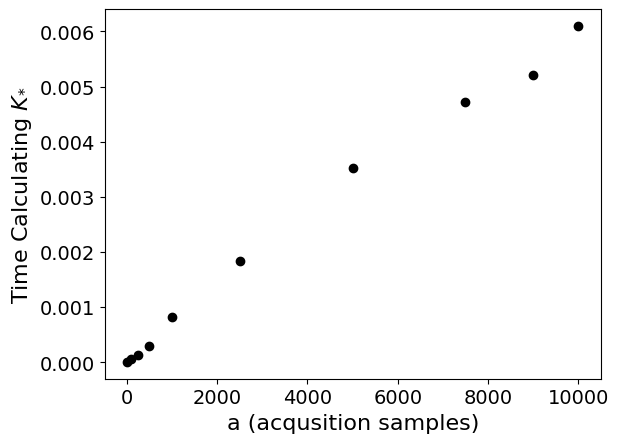

In [104]:
plt.scatter(a, np.array(K_star), color='k')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('a (acqusition samples)', fontsize=16)
plt.ylabel('Time Calculating $K_{*}$', fontsize=16)

print(np.mean(K_star_scaling), K_star_scaling)

2.310346609391251 [1.3080858115321516, 2.2013819206665253, 1.9479545811738659, 2.6024717867931195, 1.7938037902310184, 1.833675838890228, 1.9411750598132949, 2.733599116113487, 4.430971579307569]


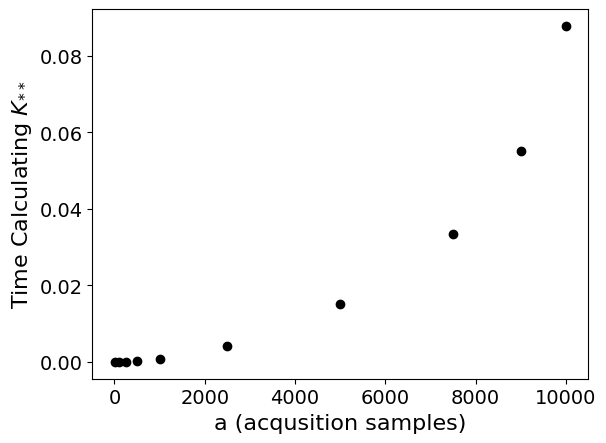

In [105]:
plt.scatter(a, np.array(K_star_star), color='k')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('a (acqusition samples)', fontsize=16)
plt.ylabel('Time Calculating $K_{**}$', fontsize=16)

print(np.mean(K_star_star_scaling), K_star_star_scaling)

1.5191053848082876 [0.29533827623682535, 0.7665946579068327, 1.333330384338549, 1.2040244160738107, 1.194954815847684, 1.596625086073147, 2.002293760696332, 2.146039659880468, 3.1327474062209406]


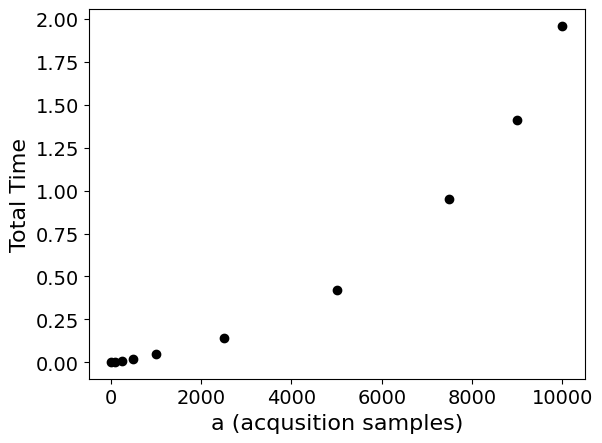

In [106]:
plt.scatter(a, np.array(All_X), color='k')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('a (acqusition samples)', fontsize=16)
plt.ylabel('Total Time', fontsize=16)

print(np.mean(All_X_scaling), All_X_scaling)